regression 预测一个数
classification 预测一个类别
Structured Learning：输出一个“有结构的东西

label 叫做正确的数值

loss越小拟合的越好.也可以是负值，看自己是怎么定义的
MAE(mean absolute error)
MSE(mean square error)依据需求来决定用哪个0

### 为什么实际上没有local minima的问题

分析loss不够低的问题
一，model bias（模型偏差）
模型设计能力不够(bias越大，越不自由，有可能是好事，正确的选择的范围小了，模型更容易选择；bias越小，越自由)
1增加更多的feature,设一个更大的model
2用deep learning 来增加模型的弹性(模型能够表示多丰富，多复杂函数的能力)
二，optimization issue（优化问题）
模型可以，但是参数没找好
gradient descent这个算法可能卡在了local minima,

如何区分到底是model bias还是optimization issue的问题？
如果deep learning的layer大的反而比小的loss高是optimization出现了问题(layer n能够解决的问题，layer n+1一定能解决)

hyperparameter超参数（自己设的不是机器找出来的）batch size, sigmoid

1 epoch=1000batch(example=10000,batch=10,update=1000)
1 epoch=10batch(example=1000,batch=100,update=10)
 
 rectified linear unit(ReLU)(cmax(0,b+wx1))
 把多个ReLU叠起来就是hard sigmoid

 最常见的activation function:sigmoid ,ReLU 

overfitting:在训练资料上变好，但测试集上没有变好
function的flexible太大了，导致freestyle,出现了
解决办法：
1.增加训练资料（增加描点数）
    a.data augmentation(把一个图片左右翻转，放大，很少上下颠倒（现实不合理)）
    b.上网找
2.规定模型的function类型（一定是二次曲线or?）
3.less parameters减少参数
4.sharing parameters共享参数（CNN,目前还不太理解）
5.less features
6.early stopping
7.regularization正则化

所以control提高了（模型过于单一）会出现model bias的问题，fexibility提高了会出现overfitting的问题，如果training loss和validation都很高那就是model bias但如果training loss很低，validation loss很高那就是overfitting


训练三步骤：
step 1:function with unknown
有未知数的function(未知数是θ)(input x 叫做feature)

step 2:define loss from training data
定义loss判断参数设定的好不好

step 3:optimization

full-connected是一个较有弹性的
CNN是一种比较没有弹性的model(针对图像，有限制，所以在影响上会做的比较好)

控制过多或者过少都不是最优的，所以需要找一个中庸的，但不能用多个模型看结果，也就是不能拿着结果找模型，这个模型可能只是巧合的适合这一个数据集，也有可能是反复的调整让模型猜到了结果（leaderboard overfitting），所以需要一个private data（训练时得不到测试结果的）
所以我们需要自己制造"private data",留一小部分的training data(validation)来衡量模型，这时public testing data和private testing data都相对的变成了private data

如果optimization失败了怎么办？
gradient为0的:local minima,saddle point
loss没有再下降是因为卡在了critical point(不要说local minima,因为还有saddle point)
为什么要有batch
大的batch会造成optimization的问题
大的batch size倾向让我们走到flat minima 里面，gradient的比较stable,每一个epoch的time会更快
小的batch size倾向让我们走到sharp minima 里面,gradient的比较nosiy，每一个epoch的time会较慢 
learning rate太大了就会在local minima附件一直振荡
learning rate太小了就会走不到local minima
所以客制化：在陡的地方smaller learning rate
在平缓的地方larger learning rate

more parameters,easier to overfit why?
i.i.d=每个数据互不影响，而且都是按同一种规则随机抽来的
所以可以用h(train)来找h(all)
所以选择合适的train很重要
模型的复杂度越低（H），样本数量越大（N），要求的越低，获得bad train的概率越低
过小的H会使理想崩坏



batch normalization适用于batch比较大的时候
让不同的dimension有同样的范围
feature normalization(标准化)
一般用re



深度学习到底好在哪里？
why hidden layer?
 deep比fat（neural多）高效很多
 1.deep需要的参数会比较少（不太会overfitting）
 2.


CNN
receptive field彼此之间是可以重叠的
一般来说
akk channels,lernel size是3*3的范围，往往会有很多个nerual去检测同一个receptive field(64.128)
每一个receptive移动的像素叫做stride(这是一个超参数)，一般都是要重叠的，
那有一个receptive field有一部分超出了怎么办？（超出的部分全部看作0）
filter(共用参数)

CNN=只看局部（receptive field）+同一个检测器（parameter sharing）

每一个receptive field在检测器的作用后能变成feature map（64个filters,64个频道）

同样一个3*3的filter,nerual越深，看到的范围越大

公用同一组参数就叫做filter

pooling(池化)把图片变小 ，主要是为了减少运算量 
比较像一个active function
max pooling ：2*2一组，每一组选最大的 



self-attention
假如输入是一排向量呢？
attention is all you need

每个向量都要计算关联性



self-attention用来做语音
现在做语音辨识的时候只用取一小段的范围，因为语音信息量非常大，难以储存计算
CNN就是self-attention的特例
self-attention的弹性比CNN大，所以在数据集较小的时候CNN更有优势，数据集大了self-attention更有优势
CNN非常经典的设计思想：空间越来越小，语义越来越丰富
transformer(变形金刚)   bert
sequence to sequence (seq2seq)
语音辨识，翻译，output有多长，机器自己决定
QA可以硬是去用seq2seq
为不同任务客制化模型

优化器更新方法
gradient drsent
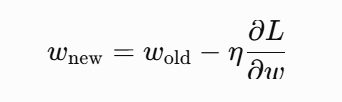
SGD（stochastic gradient desent）（随机梯度下降）
实际上就是mini-batch gradient desent
momentum(动量)
因为SGD只看当前的梯度，很有可能就在极值处来回晃荡，momentum具有惯性，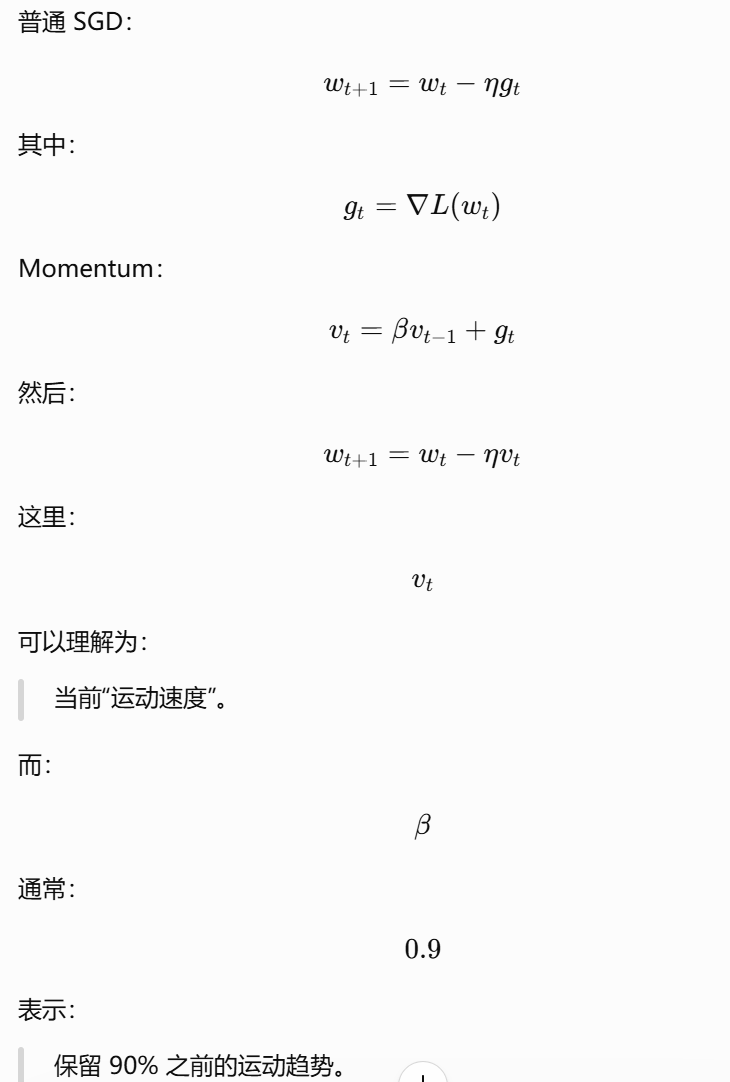
adam(adaptive moment estimation)(自适应矩估计)
momentum是看方向，adam是看油门




batch normalization &layer normalization
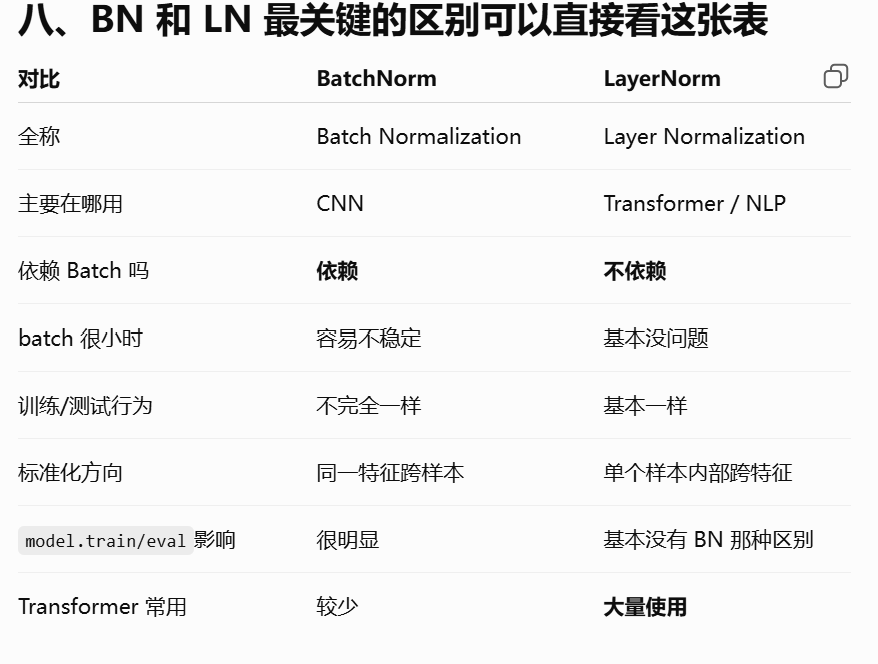

RNN(recurrent neral network)(循环神经网络)
不擅长长句关联
self-attention
直接让这个词汇去看这个句子（全部比较，但是选择性关注）
注意区别fully connected和self-attention的所有连接：fully-connected是参数学好了之后，对不同的输入使用同一组参数，self-attention关系强弱会更加输入动态变化
attention(Q我想要什么K我是什么信息V我真正的内容，QK判断应不应该关注，V看的是你关注了我会从我这里拿走什么)
masked self-attention只看它前面的，不看后面的


enbedding是把人话翻译成数字向量，encoder是这个词放在上下文里面什么意思，decorder就是根据理解生成答案

AT&NAT
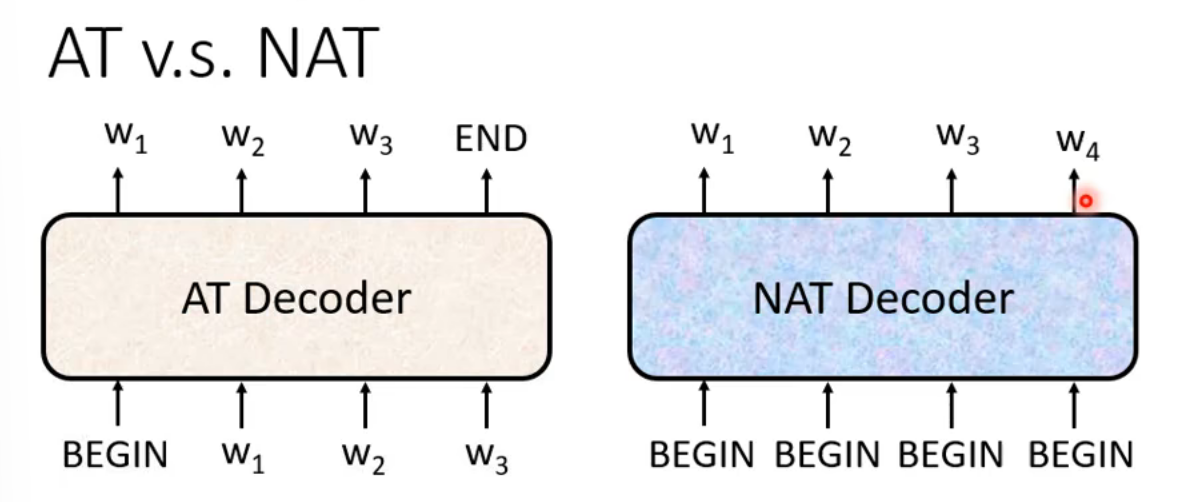

FF

# Machine Learning 学习框架整理

---

# 1. Machine Learning 的核心思想

机器学习的目标：

> 找到一个函数，使输入 x 能够得到正确输出 y。

数学表示：

$$
y=f(x)
$$

但是现实中真实函数未知，因此假设：

$$
y=f(x;\theta)
$$

其中：

- $x$：输入数据（feature）
- $y$：真实答案（label）
- $\theta$：模型参数（parameter）

机器学习就是：

> 找到最优参数 $\theta$，使模型预测结果最接近真实答案。

---

# 2. Machine Learning 三大任务

## 2.1 Regression（回归）

目标：

> 预测一个连续数值。

例如：

- 房价预测
- 股票价格预测
- 温度预测


输出：

$$
y\in R
$$


---

## 2.2 Classification（分类）

目标：

> 预测类别。


例如：

图片分类：

输入：

猫图片

输出：



### 语音识别

声音：

↓

文字


### 图片生成

文字：

↓

图片


---

# 3. Machine Learning 三个训练步骤


## Step 1：Define Function

建立模型：

$$
y=f(x;\theta)
$$


例如：

线性模型：

$$
y=b+wx
$$


未知参数：

- $w$
- $b$


神经网络：

- weight
- bias


---

## Step 2：Define Loss Function

Loss用于衡量：

> 模型预测值和真实值之间的差距。


目标：

$$
Loss \rightarrow min
$$


---

# 常见Loss函数


## MAE

Mean Absolute Error


$$
MAE=
\frac1N\sum |y-\hat y|
$$


特点：

- 对异常值不敏感


---

## MSE

Mean Square Error


$$
MSE=
\frac1N\sum(y-\hat y)^2
$$


特点：

- 大错误惩罚更严重


例如：

误差：

$$
10
$$

MSE：

$$
10^2=100
$$


---

## Step 3：Optimization

目标：

寻找：

$$
\theta
$$

使：

$$
Loss(\theta)
$$

最小。


常用方法：

Gradient Descent（梯度下降）

---

# 4. Model Bias 与 Optimization Issue


模型训练不好主要有两个原因：

---

# 4.1 Model Bias（模型偏差）


含义：

> 模型能力不足，无法表示真实规律。


例如：

真实关系：

复杂曲线


但是模型：

只能拟合直线。


无论怎么训练：

都无法得到好结果。


---

## 解决方法


### 1. 增加Feature

例如预测房价：

原：

- 面积


增加：

- 地段
- 楼龄
- 学区


---

### 2. 增大模型


例如：

10个neuron

↓

100个neuron


---

### 3. Deep Learning

增加网络深度。

提高模型表达能力。


---

# 4.2 Optimization Issue（优化问题）


模型能力足够：

但是：

参数没有找到。


原因：

Gradient Descent可能卡住：

- local minimum
- saddle point


因此：

loss停止下降不一定是local minimum。

应该称：

critical point。


---

# 如何判断是哪一个问题？


比较不同模型：

如果：

大模型loss更低：

说明：

小模型存在bias。


如果：

大模型loss反而更高：

说明：

optimization失败。


因为：

大模型理论上包含小模型。


---

# 5. Hyperparameter（超参数）


定义：

> 人为设置，而不是模型学习得到的参数。


例如：

- learning rate
- batch size
- layer数量
- neuron数量


---

# 6. Epoch 和 Batch


假设：

训练数据：

10000个。


batch size：

10


一次更新：

使用10个数据。


那么：

$$
10000/10=1000
$$


一次epoch：

1000次update。


---

# 7. Activation Function


## 为什么需要Activation Function？


如果没有：

多层神经网络仍然只是线性模型。


例如：

$$
y=w_1x
$$


第二层：

$$
z=w_2y
$$


得到：

$$
z=w_2w_1x
$$


仍然：

$$
z=wx
$$


没有增加表达能力。


---

# 常见Activation Function


## Sigmoid


输出：

$$
0\sim1
$$


常用于概率。


---

## ReLU


公式：

$$
ReLU(x)=max(0,x)
$$


作用：

增加非线性。


---

# 8. Overfitting（过拟合）


定义：

> 模型在训练数据上表现很好，但是测试数据表现差。


表现：


Training loss：

低


Validation loss：

高


---

原因：

模型过于复杂：

学习了训练数据中的噪声。


---

# 解决Overfitting


## 1. 增加训练数据


### Data Augmentation

数据增强。


例如：

图片：

- 左右翻转
- 裁剪
- 放大


注意：

上下翻转通常不合理。


---

## 2. 限制模型复杂度


规定模型形式。


---

## 3. Reduce Parameters

减少参数数量。


---

## 4. Parameter Sharing

参数共享。


例如：

CNN。


---

## 5. Reduce Features

减少输入feature。


---

## 6. Early Stopping


当：

validation loss开始增加


停止训练。


---

# 9. Validation 为什么需要？


不能：

不断根据test结果调整模型。


否则：

产生：

Leaderboard Overfitting。


---

数据划分：
Training Data

用于训练

Validation Data

用于调整模型

Testing Data

最终评价


---

# 10. Batch Size影响


## Large Batch


优点：

- gradient稳定
- 每个epoch速度快


缺点：

容易进入：

sharp minima


---

## Small Batch


特点：

gradient noisy。


优点：

容易找到：

flat minima


泛化能力可能更好。


---

# 11. Learning Rate


## 太大


结果：

不断跳过最低点。


表现：

震荡。


---

## 太小


结果：

下降速度慢。


---

理想：

动态调整：

- 陡峭区域：小learning rate
- 平缓区域：大learning rate


---

# 12. Normalization


## Feature Normalization


目的：

让不同feature范围一致。


例如：

年龄：

0-100


收入：

0-1000000


需要标准化。


---

## Batch Normalization


让不同batch的数据分布更加稳定。


---

# 13. Deep Learning 为什么有效？


## Deep vs Fat


### Fat Network

增加神经元数量。


问题：

参数多。


容易overfitting。


---

### Deep Network

增加层数。


优势：


## 1. 参数更少


同样能力：

deep模型需要更少参数。


减少overfitting。


---

## 2. 学习层级特征


例如图片：


第一层：

边缘


第二层：

纹理


第三层：

眼睛


第四层：

脸


---

# 14. CNN


CNN核心：

> Local Receptive Field + Parameter Sharing


---

# Receptive Field


神经元观察区域。


例如：

3×3 filter：

观察：

9个pixel。


---

# Filter


共享参数的检测器。


例如：

一个filter：

检测边缘。


移动到不同位置：

仍然检测边缘。


---

# Stride


filter每次移动的距离。


是超参数。


---

# Padding


当filter超过图片边界：

补0。


---

# Feature Map


filter扫描图片后：

产生新的特征。


如果：

64个filter


得到：

64个channel。


---

# CNN公式理解


CNN：

=

局部观察

+

参数共享


---

# Pooling


作用：

降低图片尺寸。


目的：

减少计算量。


---

## Max Pooling


例如：

2×2区域：
1 5
2 3

取最大值：
5


---

# Machine Learning 总流程

Machine Learning
    |
    
    |
    Define Function
|
|
f(x;θ)
|
|
Define Loss
|
|
Optimization
|
|
Gradient Descent